1. Input Data

In [1]:
import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    os.environ["PYTHONHASHSEED"] = str(seed)

set_seed(42)


In [2]:
import numpy as np
import torch

# Input data
data = np.load("frozen_soil_sensor_dataset_train_80.npz")

all_T        = data["all_T"]         # (n_case, Nt, Nz)   
all_T_sensor = data["all_T_sensor"]  # (n_case, Nt, n_s)  
params_arr   = data["params_arr"]    # (n_case, n_param)  SFCC parameter
curve_ids    = data["curve_ids"]     # (n_case,)
t            = data["t"]             # (Nt,)
z            = data["z"]             # (Nz,)
sensor_z     = data["sensor_z"]      # (n_s,)
sensor_idx   = data["sensor_idx"]    # (n_s,)

print("all_T       :", all_T.shape)
print("all_T_sensor:", all_T_sensor.shape)
print("params_arr  :", params_arr.shape)
print("curve_ids   :", curve_ids.shape)
print("t           :", t.shape)
print("z           :", z.shape)
print("sensor_z    :", sensor_z)
print("sensor_idx  :", sensor_idx)

all_T       : (80, 61, 49)
all_T_sensor: (80, 61, 11)
params_arr  : (80, 6)
curve_ids   : (80,)
t           : (61,)
z           : (49,)
sensor_z    : [0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55]
sensor_idx  : [ 4  8 12 16 20 24 28 32 36 40 44]


2. Inverse DeepONet Development

2.1. reshape

In [3]:
X_sensor_np = all_T_sensor
X_sensor = torch.from_numpy(X_sensor_np).permute(0, 2, 1).float()
params   = torch.from_numpy(params_arr).float()

print("X_sensor for CNN:", X_sensor.shape)
print("params          :", params.shape)


X_sensor for CNN: torch.Size([80, 11, 61])
params          : torch.Size([80, 6])


2.2. NN architecture

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class BranchCNN(nn.Module):
    def __init__(self, n_sensors: int, latent_dim: int = 64):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_sensors, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.Conv1d(16, 32, kernel_size=5, padding=2),
            nn.ReLU(),
        )
    
        self.pool = nn.AdaptiveAvgPool1d(1)  # Average Temp
        self.ln   = nn.LayerNorm(32)
        self.fc   = nn.Linear(32, latent_dim)

    def forward(self, x):
        # x: (B, n_sensors, Nt)
        h = self.conv(x)              # (B, 32, Nt)
        h = self.pool(h).squeeze(-1)  # (B, 32)
        h = self.ln(h)
        b = self.fc(h)                # (B, latent_dim = p)
        return b


class TrunkNet(nn.Module):
    def __init__(self, latent_dim: int = 64, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.Tanh(),
            nn.Linear(hidden, latent_dim)
        )

    def forward(self, T_query):          
        if T_query.dim() == 1:
            x = T_query.unsqueeze(-1)    # (n_T, 1)
        else: 
            x = T_query.unsqueeze(-1)
        t = self.net(x)                  # (..., latent_dim)
        return t


class InverseDeepONetMonotone(nn.Module):
    def __init__(self,
                 n_sensors: int,
                 latent_dim: int = 8,
                 theta_sat: float = 0.5):
        super().__init__()
        self.branch     = BranchCNN(n_sensors, latent_dim)
        self.trunk      = TrunkNet(latent_dim)
        self.theta_sat  = theta_sat
        self.latent_dim = latent_dim  
        self.fc_res = nn.Linear(latent_dim, 1)   
        self.fc_scale = nn.Linear(latent_dim, 1)

    def forward(self, X_sensor, T_query):
   
        device = X_sensor.device
        T_query = T_query.to(device)

        B   = X_sensor.size(0)
        n_T = T_query.numel()

        mask_neg = (T_query < 0)          # (n_T,)
        mask_pos = ~mask_neg              # (n_T,)

        idx_neg = torch.nonzero(mask_neg, as_tuple=False).squeeze(-1)  # (n_T_neg,)
        idx_pos = torch.nonzero(mask_pos, as_tuple=False).squeeze(-1)  # (n_T_pos,)

        T_neg = T_query[idx_neg]          # (n_T_neg,)

        # b: (B, latent_dim)
        b = self.branch(X_sensor)         # (B, latent_dim)

        theta_res_frac = torch.sigmoid(self.fc_res(b))   # (B, 1), 0~1
        theta_res = theta_res_frac * self.theta_sat      # (B, 1)

        t_neg = self.trunk(T_neg)         # (n_T_neg, latent_dim)

        # raw: (B, n_T_neg)
        theta_raw_neg = torch.matmul(b, t_neg.T)   # (B, n_T_neg)

        scale = 0.2 + 5.0 * torch.sigmoid(self.fc_scale(b))   # (B,1) > 0
        delta = F.softplus(theta_raw_neg) * scale              # (B,n_T_neg)
        theta_cum = torch.cumsum(delta, dim=1)     # (B, n_T_neg)

        eps = 1e-6
        s_neg = theta_cum / (theta_cum[:, -1:].clone() + eps)   # (B, n_T_neg), 0~1
        theta_neg = theta_res + (self.theta_sat - theta_res) * s_neg  # (B, n_T_neg)
        theta = torch.zeros(B, n_T, device=device)

        if idx_neg.numel() > 0:
            theta[:, idx_neg] = theta_neg

        if idx_pos.numel() > 0:
            theta[:, idx_pos] = self.theta_sat

        return theta

3. Reference SFCC Labels

In [5]:
theta_sat = 0.5

T_query = torch.linspace(
    -15.0,
    0.0,
    50,
    dtype=torch.float32,
)


def build_form2_sfcc_labels(
    params,
    T_query,
    theta_sat=0.5,
):
    theta_res = params[:, 3:4]
    gamma = params[:, 4:5].clamp_min(1e-6)

    T = T_query.reshape(1, -1)

    theta_true = theta_res + (theta_sat - theta_res) * torch.exp(-(T / gamma) ** 2)

    return theta_true.clamp(
        0.0,
        theta_sat,
    )


Y_sfcc = build_form2_sfcc_labels(
    params=params,
    T_query=T_query,
    theta_sat=theta_sat,
)

print("Temperature input:", X_sensor.shape)
print("Reference SFCC:", Y_sfcc.shape)
print("Temperature query:", T_query.shape)

Temperature input: torch.Size([80, 11, 61])
Reference SFCC: torch.Size([80, 50])
Temperature query: torch.Size([50])


4. Supervised Loss and Training

In [6]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

set_seed(42)

n_sensors = X_sensor.shape[1]
latent_dim = 8

supervised_dion = InverseDeepONetMonotone(
    n_sensors=n_sensors,
    latent_dim=latent_dim,
    theta_sat=0.5,
).to(device)

4.1. Training Setup

In [7]:
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(
    X_sensor,
    Y_sfcc,
)

train_loader = DataLoader(
    dataset,
    batch_size=10,
    shuffle=True,
    drop_last=False,
)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    supervised_dion.parameters(),
    lr=1e-3,
)

n_epochs = 200

loss_hist = []

4.2. Direct Supervised Training

In [8]:
import time

if device.type == "cuda":
    torch.cuda.synchronize()

training_start = time.perf_counter()

for epoch in range(1, n_epochs + 1):

    supervised_dion.train()

    running_loss = 0.0
    n_seen = 0

    for X_batch, theta_true_batch in train_loader:

        X_batch = X_batch.to(device)
        theta_true_batch = theta_true_batch.to(device)

        optimizer.zero_grad()

        theta_pred_batch = supervised_dion(
            X_batch,
            T_query,
        )

        loss = criterion(
            theta_pred_batch,
            theta_true_batch,
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            supervised_dion.parameters(),
            max_norm=1.0,
        )

        optimizer.step()

        batch_size_actual = X_batch.shape[0]

        running_loss += (
            loss.item() * batch_size_actual
        )

        n_seen += batch_size_actual

    epoch_loss = running_loss / n_seen
    loss_hist.append(epoch_loss)

    print(
        f"Epoch {epoch:03d} | "
        f"SFCC loss={epoch_loss:.6e}"
    )

if device.type == "cuda":
    torch.cuda.synchronize()

supervised_training_time = time.perf_counter() - training_start

print(
    f"Supervised DION training time: "
    f"{supervised_training_time:.2f} s "
    f"({supervised_training_time / 60:.2f} min)"
)

Epoch 001 | SFCC loss=2.164160e-02
Epoch 002 | SFCC loss=1.319154e-02
Epoch 003 | SFCC loss=1.340905e-02
Epoch 004 | SFCC loss=1.296877e-02
Epoch 005 | SFCC loss=1.299453e-02
Epoch 006 | SFCC loss=1.290846e-02
Epoch 007 | SFCC loss=1.254738e-02
Epoch 008 | SFCC loss=1.313605e-02
Epoch 009 | SFCC loss=1.523137e-02
Epoch 010 | SFCC loss=1.297566e-02
Epoch 011 | SFCC loss=1.301163e-02
Epoch 012 | SFCC loss=1.269989e-02
Epoch 013 | SFCC loss=1.244342e-02
Epoch 014 | SFCC loss=1.236315e-02
Epoch 015 | SFCC loss=1.227509e-02
Epoch 016 | SFCC loss=1.223383e-02
Epoch 017 | SFCC loss=1.203764e-02
Epoch 018 | SFCC loss=1.145467e-02
Epoch 019 | SFCC loss=1.175238e-02
Epoch 020 | SFCC loss=1.046296e-02
Epoch 021 | SFCC loss=7.955280e-03
Epoch 022 | SFCC loss=5.039858e-03
Epoch 023 | SFCC loss=4.667640e-03
Epoch 024 | SFCC loss=4.530830e-03
Epoch 025 | SFCC loss=4.516890e-03
Epoch 026 | SFCC loss=3.930648e-03
Epoch 027 | SFCC loss=3.244905e-03
Epoch 028 | SFCC loss=4.071872e-03
Epoch 029 | SFCC los

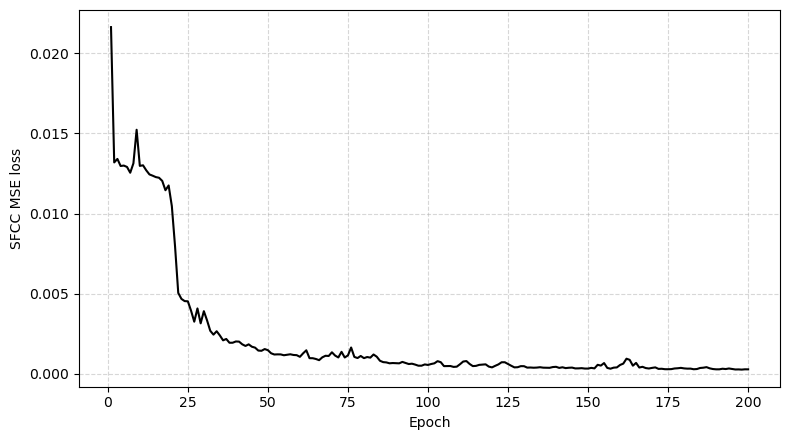

In [9]:
import matplotlib.pyplot as plt
import numpy as np

epochs = np.arange(
    1,
    len(loss_hist) + 1,
)

plt.figure(figsize=(8, 4.5))

plt.plot(
    epochs,
    loss_hist,
    color="black",
)

#plt.yscale("log")
plt.xlabel("Epoch")
plt.ylabel("SFCC MSE loss")
plt.grid(
    True,
    which="both",
    linestyle="--",
    alpha=0.5,
)

plt.tight_layout()
plt.show()

In [10]:
test_data = np.load("frozen_soil_sensor_dataset_test_corrected.npz")

all_T_sensor_test = test_data["all_T_sensor"]

params_arr_test = test_data["params_arr"]

curve_ids_test = test_data["curve_ids"]


X_sensor_test = torch.from_numpy(
    all_T_sensor_test
).permute(0, 2, 1).float()

params_test = torch.from_numpy(
    params_arr_test
).float()


Y_sfcc_test = build_form2_sfcc_labels(
    params=params_test,
    T_query=T_query,
    theta_sat=theta_sat,
)


print("Test temperature input:",
      X_sensor_test.shape)

print("Test reference SFCC:",
      Y_sfcc_test.shape)

Test temperature input: torch.Size([220, 11, 61])
Test reference SFCC: torch.Size([220, 50])


In [11]:
supervised_dion.eval()

X_test_cuda = X_sensor_test.to(device)
T_query_cuda = T_query.to(device)

# 预热一次
with torch.no_grad():
    _ = supervised_dion(X_test_cuda, T_query_cuda)

torch.cuda.synchronize()
inference_start = time.perf_counter()

with torch.no_grad():
    theta_pred_test = supervised_dion(
        X_test_cuda,
        T_query_cuda,
    )

torch.cuda.synchronize()
supervised_inference_time = time.perf_counter() - inference_start

print(
    f"Inference time for 220 cases: "
    f"{supervised_inference_time * 1000:.3f} ms"
)

print(
    f"Average inference time per case: "
    f"{supervised_inference_time / 220 * 1000:.6f} ms"
)


theta_pred_test = (theta_pred_test.cpu())

print("Predicted test SFCC:",theta_pred_test.shape,)

Inference time for 220 cases: 2.073 ms
Average inference time per case: 0.009420 ms
Predicted test SFCC: torch.Size([220, 50])


In [12]:
theta_pred_test_np = (
    theta_pred_test.numpy()
)

theta_true_test_np = (
    Y_sfcc_test.numpy()
)


# Global RMSE
test_rmse = np.sqrt(
    np.mean(
        (
            theta_pred_test_np
            - theta_true_test_np
        ) ** 2
    )
)


# Global R2
ss_res = np.sum(
    (
        theta_true_test_np
        - theta_pred_test_np
    ) ** 2
)

ss_tot = np.sum(
    (
        theta_true_test_np
        - np.mean(theta_true_test_np)
    ) ** 2
)

test_r2 = 1.0 - ss_res / ss_tot


print(
    f"Test SFCC RMSE = {test_rmse:.6f}"
)

print(
    f"Test SFCC R2   = {test_r2:.6f}"
)

Test SFCC RMSE = 0.027230
Test SFCC R2   = 0.933843


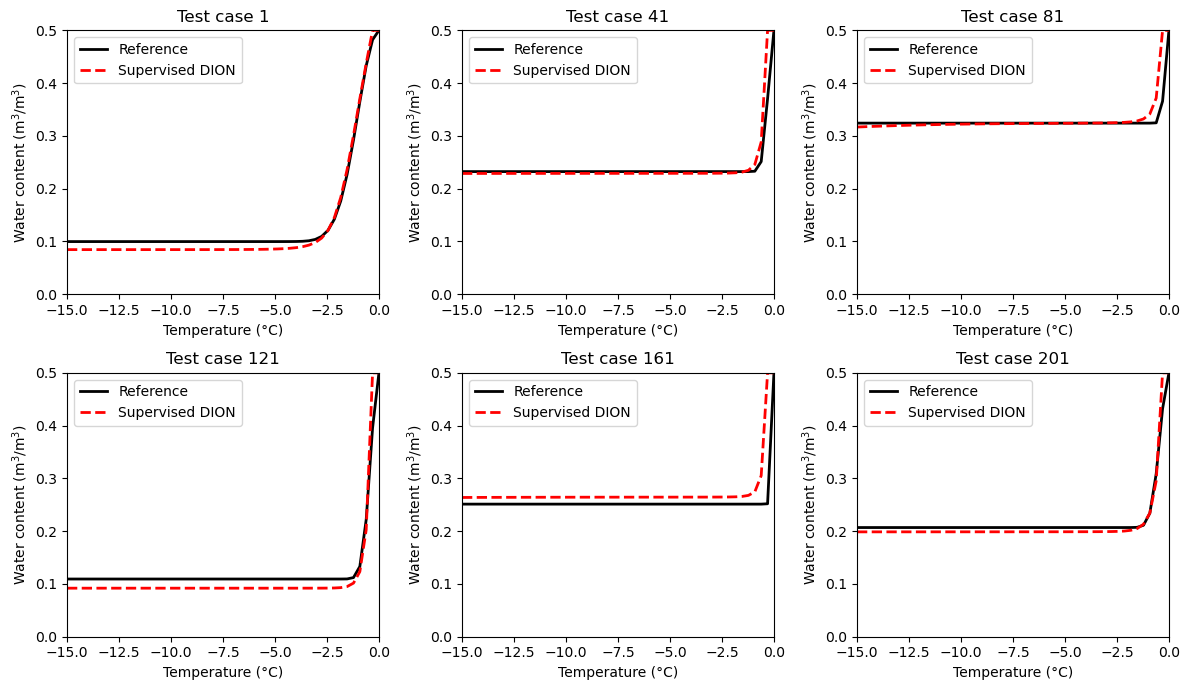

In [13]:
import matplotlib.pyplot as plt

selected_cases = [0, 40, 80, 120, 160, 200]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 7),
)

for ax, case_idx in zip(
    axes.flat,
    selected_cases,
):

    ax.plot(
        T_query.numpy(),
        theta_true_test_np[case_idx],
        color="black",
        linewidth=2,
        label="Reference",
    )

    ax.plot(
        T_query.numpy(),
        theta_pred_test_np[case_idx],
        color="red",
        linestyle="--",
        linewidth=2,
        label="Supervised DION",
    )

    ax.set_title(
        f"Test case {curve_ids_test[case_idx]}"
    )

    ax.set_xlim(-15, 0)
    ax.set_ylim(0, 0.5)
    ax.set_xlabel("Temperature (°C)")
    ax.set_ylabel(
        r"Water content (m$^3$/m$^3$)"
    )

    ax.legend()

plt.tight_layout()
plt.show()

In [15]:
supervised_weight_path = (
    r"D:\UW Madsion\Operator\SFC_inverse\Operator experiment"
    r"\SC_DION\Baseline_supervised_DION_Train_80"
    r"\supervised_dion_train_80.pt"
)

torch.save(
    supervised_dion.state_dict(),
    supervised_weight_path
)

print("Saved:", supervised_weight_path)

Saved: D:\UW Madsion\Operator\SFC_inverse\Operator experiment\SC_DION\Baseline_supervised_DION_Train_80\supervised_dion_train_80.pt
